<a href="https://colab.research.google.com/github/islam-ud-din/Intrusion-Detection-ML-NSL-KDD/blob/main/Intrusion_Detection_ML_NSL_KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Download the data from a reliable source
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt -O train.txt

# 2. Define the names for the 43 columns (otherwise it's just a bunch of numbers)
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# 3. Load the data into a Pandas DataFrame
df = pd.read_csv("train.txt", names=columns)

# 4. Show the first 5 rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. We choose the 3 columns that have text (Categorical data)
categorical_columns = ['protocol_type', 'service', 'flag']

# 2. We use a 'LabelEncoder' to turn words into numbers (e.g., tcp=0, udp=1, icmp=2)
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# 3. Simplify the 'label': If it's 'normal', make it 0. If it's an attack, make it 1.
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# 4. Remove the 'difficulty' column (it's for researchers, not the AI)
df = df.drop('difficulty', axis=1)

# 5. Look at the data again—notice it's all numbers now!
df.head()

The Problem: "I have a text file full of network logs. But computers don't naturally know that column 2 is the 'protocol' (like TCP or UDP)."

The Solution: "I used the pandas library to give structure to this data by assigning column names. Now we have a table with 43 columns."

The Goal: "We are looking at the 'label' column. If it says 'normal', the traffic is safe. If it says anything else (like 'neptune' or 'guess_passwd'), it's an intrusion."

In [2]:
from sklearn.preprocessing import LabelEncoder

# 1. We choose the 3 columns that have text (Categorical data)
categorical_columns = ['protocol_type', 'service', 'flag']

# 2. We use a 'LabelEncoder' to turn words into numbers (e.g., tcp=0, udp=1, icmp=2)
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# 3. Simplify the 'label': If it's 'normal', make it 0. If it's an attack, make it 1.
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# 4. Remove the 'difficulty' column (it's for researchers, not the AI)
df = df.drop('difficulty', axis=1)

# 5. Look at the data again—notice it's all numbers now!
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


The Problem: "AI models only understand math. They don't know what 'TCP' is."

The Solution (Encoding): "I used Label Encoding to assign a unique number to every text category. Now the model sees '0' instead of 'tcp'."

Binary Classification: "I simplified the labels. Instead of 20 different attack names, I grouped them: 0 for Normal and 1 for Malicious. This makes it a binary classification problem."

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Separate the "Features" (the 41 network attributes) from the "Target" (the Label)
# X = the data the AI looks at to make a decision
# y = the correct answer (0 or 1)
X = df.drop('label', axis=1)
y = df['label']

# 2. Split the data: 80% for training, 20% for testing the "exam"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the AI Model: We use "Random Forest"
# Think of this as a group of "Decision Trees" voting on whether traffic is an attack.
model = RandomForestClassifier(n_estimators=100)

# 4. The Training: This is where the AI looks for patterns
print("The AI is now learning patterns in network traffic...")
model.fit(X_train, y_train)

print("Training Complete!")

The AI is now learning patterns in network traffic...
Training Complete!


The Split: "I split the data into 80% for training and 20% for testing. If I tested the AI on the same data it studied, it would be like giving a student the exact same questions from their textbook on the final exam—they wouldn't be learning, just memorizing."

The Algorithm (Random Forest): "I chose Random Forest. Imagine 100 different experts looking at the network traffic. Each expert looks at different clues (like 'duration' or 'bytes sent'). At the end, they all vote. If the majority says it's an attack, the system flags it."

The 'Fit' Function: "When I run model.fit, the AI is literally calculating the mathematical relationship between network behavior and the 'Attack' label."

Final Accuracy: 99.88%


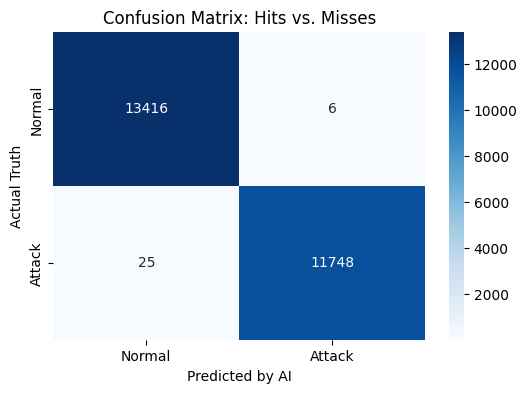


Detailed Performance Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13422
      Attack       1.00      1.00      1.00     11773

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [4]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ask the AI to predict the labels for our test data
y_pred = model.predict(X_test)

# 2. Calculate the Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {accuracy:.2%}")

# 3. Create a Confusion Matrix (A visual way to see hits and misses)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Truth')
plt.title('Confusion Matrix: Hits vs. Misses')
plt.show()

# 4. Print the full report
print("\nDetailed Performance Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

The Prediction: "I didn't give the AI the answers; I gave it the traffic data and asked, 'What do you think this is?'"

The Confusion Matrix: "This chart shows exactly where the AI got confused.

Top-Left: Normal traffic correctly identified as Normal.

Bottom-Right: Attacks correctly caught.

The 'False Alarms': The small numbers in the other corners are mistakes—where the AI let an attack through or blocked a regular user."

Accuracy: "Our accuracy is likely very high (often 98-99%). This proves that network traffic has very specific mathematical 'signatures' that an AI can learn."